# Clasificación de Peces: CNN Propia vs ResNet50 vs VGG16

**Dataset:** [A Large Scale Fish Dataset](https://www.kaggle.com/crowww/a-large-scale-fish-dataset)  
**Tarea:** Clasificación multiclase — 9 especies de peces

## Arquitecturas comparadas

| | Modelo A | Modelo B | Modelo C |
|---|---|---|---|
| **Backbone** | CNN propia (desde cero) | ResNet50 (ImageNet) | VGG16 (ImageNet) |
| **Clasificador** | FishMLP | FishMLP | FishMLP |
| **Entrenamiento** | Todo desde cero | Transfer Learning | Transfer Learning |
| **Parámetros backbone** | ~1.2M | ~23.5M | ~14.7M |

La **MLP es idéntica** en los tres modelos. La única variable que cambia es el backbone, lo que hace la comparación justa.

## Justificación de decisiones

**¿Por qué Transfer Learning en ResNet50 y VGG16?**  
Ambos están preentrenados en ImageNet y ya aprendieron features visuales generales transferibles a clasificación de peces. Se usa la misma estrategia de dos fases en ambos:
- Fase 1: backbone congelado, solo se entrena la MLP
- Fase 2: fine-tuning de las últimas capas convolucionales

**¿Por qué comparar ResNet50 vs VGG16?**  
Son dos filosofías de diseño distintas: ResNet50 usa conexiones residuales (skip connections) que permiten entrenar redes más profundas sin degradación del gradiente. VGG16 es una arquitectura secuencial más simple y más antigua, sin skip connections. Compararlos permite ver si la arquitectura del backbone impacta la accuracy final cuando ambos parten de ImageNet.

**¿Por qué CNN propia desde cero?**  
Para medir cuánto aporta el preentrenamiento. Si la CNN propia se acerca a los modelos preentrenados, el dataset es suficientemente grande. Si los modelos preentrenados ganan ampliamente, confirma el valor del Transfer Learning.

## 0. Instalación y Setup

In [27]:
!pip install -q kaggle matplotlib seaborn scikit-learn

In [28]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# Copiar kaggle.json desde Drive (automático)
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API configurada')

Kaggle API configurada


In [30]:
!kaggle datasets download -d crowww/a-large-scale-fish-dataset -p /content/fish_data --unzip
print('Dataset descargado')

Dataset URL: https://www.kaggle.com/datasets/crowww/a-large-scale-fish-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.24G/3.24G [00:26<00:00, 133MB/s]

Dataset descargado


## 1. Imports y configuración global

In [31]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights
from torchvision.models import VGG16_Weights
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Hiperparámetros ──
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_CLASSES  = 9

# Modelo A: CNN propia + MLP
EPOCHS_A     = 20
LR_A         = 1e-3

# Modelo B: ResNet50 + MLP
EPOCHS_B1    = 8   # Fase 1: solo MLP
EPOCHS_B2    = 8   # Fase 2: fine-tuning
LR_B1        = 1e-3
LR_B2        = 1e-4

# Modelo C: VGG16 + MLP
EPOCHS_C1    = 8   # Fase 1: solo MLP
EPOCHS_C2    = 8   # Fase 2: fine-tuning
LR_C1        = 1e-3
LR_C2        = 1e-4

Dispositivo: cuda
GPU: Tesla T4


## 2. Exploración del dataset

In [32]:
from pathlib import Path

BASE = Path('/content/fish_data/Fish_Dataset/Fish_Dataset')

class_paths = {}
for species_dir in sorted(BASE.iterdir()):
    if species_dir.is_dir():
        for sub in species_dir.iterdir():
            if sub.is_dir() and 'GT' not in sub.name:
                class_paths[species_dir.name] = sub
                break

print(f'Clases encontradas ({len(class_paths)}):')
for i, (name, path) in enumerate(class_paths.items()):
    n = len(list(path.glob('*.png'))) + len(list(path.glob('*.jpg')))
    print(f'  [{i}] {name}: {n} imágenes')

Clases encontradas (9):
  [0] Black Sea Sprat: 1000 imágenes
  [1] Gilt-Head Bream: 1000 imágenes
  [2] Hourse Mackerel: 1000 imágenes
  [3] Red Mullet: 1000 imágenes
  [4] Red Sea Bream: 1000 imágenes
  [5] Sea Bass: 1000 imágenes
  [6] Shrimp: 1000 imágenes
  [7] Striped Red Mullet: 1000 imágenes
  [8] Trout: 1000 imágenes


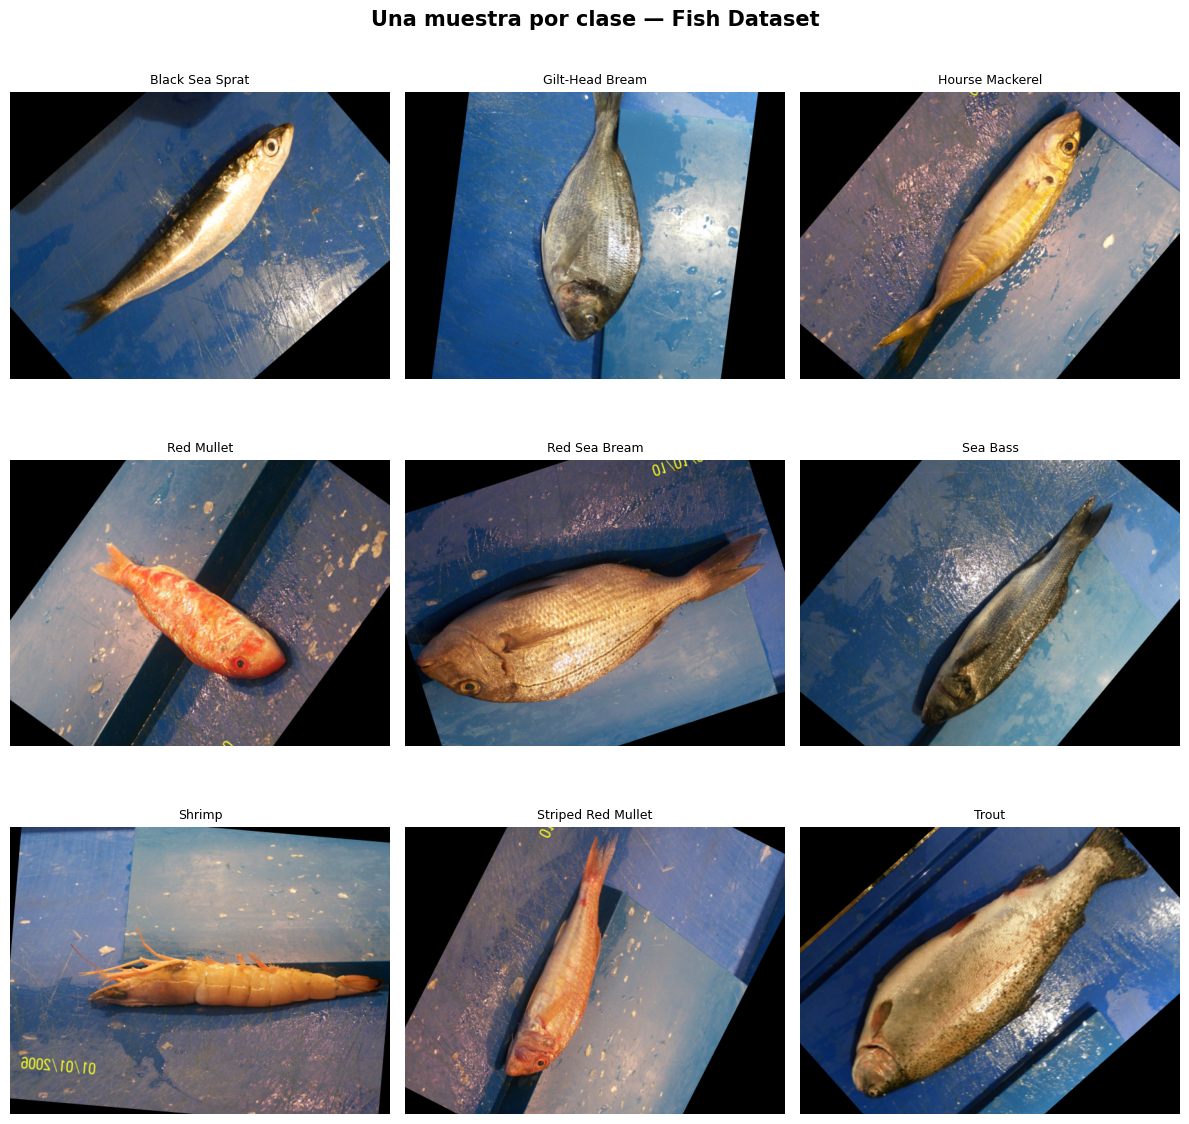

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Una muestra por clase — Fish Dataset', fontsize=15, fontweight='bold')

for ax, (name, path) in zip(axes.flat, class_paths.items()):
    imgs = list(path.glob('*.png')) + list(path.glob('*.jpg'))
    if imgs:
        ax.imshow(Image.open(imgs[0]))
        ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('samples.png', dpi=100)
plt.show()

## 3. Preprocesamiento y DataLoaders

In [34]:
import os
from pathlib import Path

# Crear estructura plana temporal que ImageFolder entiende
FLAT_DIR = Path('/content/fish_flat')
FLAT_DIR.mkdir(exist_ok=True)

for name, src_path in class_paths.items():
    dst = FLAT_DIR / name
    if not dst.exists():
        dst.symlink_to(src_path.resolve())

print('Estructura creada:')
for d in sorted(FLAT_DIR.iterdir()):
    n = len(list(d.glob('*.png'))) + len(list(d.glob('*.jpg')))
    print(f'  {d.name}: {n} imágenes')

# Transformaciones
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        x, y = self.subset[i]
        return self.transform(x), y

# Dataset y split 70/15/15
full_ds     = datasets.ImageFolder(str(FLAT_DIR))
CLASS_NAMES = full_ds.classes
N           = len(full_ds)

g       = torch.Generator().manual_seed(SEED)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val
idx     = torch.randperm(N, generator=g).tolist()

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

raw_ds = datasets.ImageFolder(str(FLAT_DIR), transform=transforms.Lambda(lambda x: x))

train_ds = TransformSubset(Subset(raw_ds, train_idx), train_tf)
val_ds   = TransformSubset(Subset(raw_ds, val_idx),   val_tf)
test_ds  = TransformSubset(Subset(raw_ds, test_idx),  val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTotal: {N} | Train: {n_train} | Val: {n_val} | Test: {n_test}')
print(f'Clases: {CLASS_NAMES}')

Estructura creada:
  Black Sea Sprat: 1000 imágenes
  Gilt-Head Bream: 1000 imágenes
  Hourse Mackerel: 1000 imágenes
  Red Mullet: 1000 imágenes
  Red Sea Bream: 1000 imágenes
  Sea Bass: 1000 imágenes
  Shrimp: 1000 imágenes
  Striped Red Mullet: 1000 imágenes
  Trout: 1000 imágenes

Total: 9000 | Train: 6300 | Val: 1350 | Test: 1350
Clases: ['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


## 4. Definición de la MLP (compartida por ambos modelos)

In [35]:
class FishMLP(nn.Module):
    """
    Cabeza clasificadora MLP compartida por ambos modelos.
    Recibe un vector de features del backbone y produce logits para 9 clases.

    Arquitectura:
        in_features → 512 → 256 → 128 → num_classes
    Con BatchNorm, ReLU y Dropout en cada capa oculta.
    """
    def __init__(self, in_features, num_classes=9):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

print('MLP definida:')
print('  in_features → 512 → 256 → 128 → 9 clases')
print('  (BatchNorm + ReLU + Dropout en cada capa oculta)')

MLP definida:
  in_features → 512 → 256 → 128 → 9 clases
  (BatchNorm + ReLU + Dropout en cada capa oculta)


## 5. Modelo A: CNN Propia + MLP

La CNN es un extractor de features hecho desde cero, con 5 bloques convolucionales.
Cada bloque tiene: Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool.
Al final, un Global Average Pooling convierte el mapa de features en un vector 1D
que entra a la MLP para clasificar.

In [36]:
class ConvBlock(nn.Module):
    """Bloque convolucional doble: Conv-BN-ReLU-Conv-BN-ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class FishCNN(nn.Module):
    """
    CNN propia para extracción de features.

    Input:  (B, 3, 224, 224)
    Block1: 3→32,   MaxPool → (B, 32,  112, 112)
    Block2: 32→64,  MaxPool → (B, 64,  56,  56 )
    Block3: 64→128, MaxPool → (B, 128, 28,  28 )
    GAP             →         (B, 128)
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),  nn.MaxPool2d(2), nn.Dropout2d(0.1),
            ConvBlock(32,  64),  nn.MaxPool2d(2), nn.Dropout2d(0.1),
            ConvBlock(64, 128), nn.MaxPool2d(2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)          # (B, 128, 1, 1)
        return x.flatten(1)      # (B, 128)


class ModeloA(nn.Module):
    """CNN propia + MLP propia. Todo entrenado desde cero."""
    def __init__(self, num_classes=9):
        super().__init__()
        self.backbone = FishCNN()
        self.mlp      = FishMLP(in_features=128, num_classes=num_classes)

    def forward(self, x):
        features = self.backbone(x)   # (B, 128)
        return self.mlp(features)     # (B, 9)


modelo_a = ModeloA(NUM_CLASSES).to(DEVICE)
params_a  = sum(p.numel() for p in modelo_a.parameters())
print(f'Modelo A — parámetros totales: {params_a:,}')
print(f'  CNN backbone : {sum(p.numel() for p in modelo_a.backbone.parameters()):,}')
print(f'  MLP          : {sum(p.numel() for p in modelo_a.mlp.parameters()):,}')

Modelo A — parámetros totales: 520,681
  CNN backbone : 287,456
  MLP          : 233,225


## 6. Modelo B: ResNet50 + MLP propio

In [37]:
class ModeloB(nn.Module):
    """
    ResNet50 preentrenado en ImageNet como backbone + la misma MLP.
    Se remueve la capa FC original de ResNet50 y se reemplaza por la FishMLP.
    """
    def __init__(self, num_classes=9, freeze_backbone=True):
        super().__init__()
        # Cargar ResNet50 preentrenado, sin la FC original
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        resnet.fc = nn.Identity()  # Quitar clasificador original → output (B, 2048)
        self.backbone = resnet

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # ResNet50 sin FC produce features de 2048 dimensiones
        self.mlp = FishMLP(in_features=2048, num_classes=num_classes)

    def unfreeze_last_block(self):
        """Descongela layer4 de ResNet para fine-tuning (Fase 2)."""
        for p in self.backbone.layer4.parameters():
            p.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)   # (B, 2048)
        return self.mlp(features)     # (B, 9)


modelo_b = ModeloB(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
params_b_total = sum(p.numel() for p in modelo_b.parameters())
params_b_train = sum(p.numel() for p in modelo_b.parameters() if p.requires_grad)
print(f'Modelo B — parámetros totales    : {params_b_total:,}')
print(f'Modelo B — parámetros entrenables: {params_b_train:,} (Fase 1, backbone congelado)')
print(f'  ResNet50 backbone: {sum(p.numel() for p in modelo_b.backbone.parameters()):,}')
print(f'  MLP              : {sum(p.numel() for p in modelo_b.mlp.parameters()):,}')

Modelo B — parámetros totales    : 24,724,297
Modelo B — parámetros entrenables: 1,216,265 (Fase 1, backbone congelado)
  ResNet50 backbone: 23,508,032
  MLP              : 1,216,265


## 7. Modelo C: VGG16 + MLP propio

Misma estrategia que el Modelo B pero con VGG16 como backbone.

**VGG16 vs ResNet50:**
- VGG16 es una arquitectura secuencial de 16 capas sin skip connections, propuesta en 2014
- ResNet50 tiene 50 capas con conexiones residuales, propuesta en 2015
- VGG16 tiene ~138M parámetros totales pero su parte convolucional tiene ~14.7M
- Ambos preentrenados en ImageNet con la misma estrategia de dos fases

**Fine-tuning:** se descongela el último bloque convolucional de VGG16 (`features[24:]`) en la Fase 2, equivalente a descongelar `layer4` en ResNet50.



In [38]:
class ModeloC(nn.Module):
    """
    VGG16 preentrenado en ImageNet como backbone + la misma FishMLP.
    Se remueve el clasificador original de VGG16 y se reemplaza por FishMLP.
    VGG16 sin classifier produce features de 512*7*7 = 25088,
    pero usando AdaptiveAvgPool2d(1) obtenemos 512 features.
    """
    def __init__(self, num_classes=9, freeze_backbone=True):
        super().__init__()
        vgg = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        # Usar solo la parte convolucional + AdaptiveAvgPool
        self.backbone = vgg.features          # capas convolucionales
        self.gap      = nn.AdaptiveAvgPool2d(1)  # → (B, 512, 1, 1)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # VGG16 features produce 512 canales → misma cantidad que ResNet sin FC
        # DISTINTO al Modelo A que produce 128 canales (CNN simplificada)
        self.mlp = FishMLP(in_features=512, num_classes=num_classes)

    def unfreeze_last_block(self):
        """Descongela el último bloque convolucional de VGG16 (features[24:])."""
        for p in self.backbone[24:].parameters():
            p.requires_grad = True

    def forward(self, x):
        x = self.backbone(x)     # (B, 512, 7, 7)
        x = self.gap(x)          # (B, 512, 1, 1)
        x = x.flatten(1)         # (B, 512)
        return self.mlp(x)       # (B, 9)


modelo_c = ModeloC(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
params_c_total = sum(p.numel() for p in modelo_c.parameters())
params_c_train = sum(p.numel() for p in modelo_c.parameters() if p.requires_grad)
print(f'Modelo C — parámetros totales    : {params_c_total:,}')
print(f'Modelo C — parámetros entrenables: {params_c_train:,} (Fase 1, backbone congelado)')
print(f'  VGG16 backbone: {sum(p.numel() for p in modelo_c.backbone.parameters()):,}')
print(f'  MLP           : {sum(p.numel() for p in modelo_c.mlp.parameters()):,}')

Modelo C — parámetros totales    : 15,144,521
Modelo C — parámetros entrenables: 429,833 (Fase 1, backbone congelado)
  VGG16 backbone: 14,714,688
  MLP           : 429,833


## 8. Funciones de entrenamiento y evaluación

In [39]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * X.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += X.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out  = model(X)
        loss = criterion(out, y)
        loss_sum += loss.item() * X.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += X.size(0)
    return loss_sum / total, correct / total

def training_loop(model, train_ldr, val_ldr, criterion, optimizer,
                  scheduler, epochs, name, save_path):
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc = 0.0
    t0 = time.time()
    for ep in range(1, epochs+1):
        tl, ta = train_epoch(model, train_ldr, criterion, optimizer)
        vl, va = eval_epoch(model, val_ldr,   criterion)
        if scheduler: scheduler.step(vl)
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        if va > best_acc:
            best_acc = va
            torch.save(model.state_dict(), save_path)
        print(f'[{name}] Ep {ep:02d}/{epochs} | '
              f'Train {ta:.4f} ({tl:.4f}) | Val {va:.4f} ({vl:.4f})'
              f"{' ← best' if va == best_acc else ''}")
    elapsed = time.time() - t0
    print(f'⏱ {elapsed/60:.1f} min | Mejor val acc: {best_acc:.4f}')
    return history, elapsed

@torch.no_grad()
def evaluate_test(model, loader, class_names, title):
    model.eval()
    preds_all, labels_all = [], []
    for X, y in loader:
        preds_all.extend(model(X.to(DEVICE)).argmax(1).cpu().numpy())
        labels_all.extend(y.numpy())
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='weighted')
    print(f'\n=== {title} ===')
    print(f'Test Accuracy : {acc:.4f}')
    print(f'Test F1 (weighted): {f1:.4f}')
    print(classification_report(labels_all, preds_all, target_names=class_names))
    return labels_all, preds_all, acc, f1

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history['train_loss'])+1)
    ax1.plot(ep, history['train_loss'], 'b-o', ms=4, label='Train')
    ax1.plot(ep, history['val_loss'],   'r-o', ms=4, label='Val')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, history['train_acc'], 'b-o', ms=4, label='Train')
    ax2.plot(ep, history['val_acc'],   'r-o', ms=4, label='Val')
    ax2.set_title('Accuracy'); ax2.set_ylim(0,1); ax2.legend(); ax2.grid(alpha=0.3)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=100)
    plt.show()

def plot_cm(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión — {title}', fontweight='bold')
    plt.ylabel('Real'); plt.xlabel('Predicho')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(f'CM_{title.replace(" ","_")}.png', dpi=100)
    plt.show()

print('Funciones definidas')

Funciones definidas


## 9. Entrenamiento Modelo A (CNN propia + MLP)

In [41]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

opt_a  = optim.AdamW(modelo_a.parameters(), lr=LR_A, weight_decay=1e-4)
sch_a  = optim.lr_scheduler.ReduceLROnPlateau(opt_a, patience=4, factor=0.5)

print('='*60)
print('MODELO A: CNN Propia + MLP — entrenando desde cero')
print('='*60)
history_a, time_a = training_loop(
    modelo_a, train_loader, val_loader, criterion, opt_a, sch_a,
    EPOCHS_A, 'Modelo A', 'modelo_a_best.pth'
)

MODELO A: CNN Propia + MLP — entrenando desde cero
[Modelo A] Ep 01/20 | Train 0.6784 (1.2088) | Val 0.8059 (0.9044) ← best
[Modelo A] Ep 02/20 | Train 0.7846 (0.9943) | Val 0.8519 (0.8179) ← best
[Modelo A] Ep 03/20 | Train 0.8225 (0.9074) | Val 0.9007 (0.7210) ← best
[Modelo A] Ep 04/20 | Train 0.8689 (0.8137) | Val 0.9415 (0.6471) ← best
[Modelo A] Ep 05/20 | Train 0.8883 (0.7796) | Val 0.9378 (0.6492)
[Modelo A] Ep 06/20 | Train 0.9075 (0.7408) | Val 0.9333 (0.6544)
[Modelo A] Ep 07/20 | Train 0.9132 (0.7167) | Val 0.9770 (0.5666) ← best
[Modelo A] Ep 08/20 | Train 0.9205 (0.7033) | Val 0.9667 (0.5704)
[Modelo A] Ep 09/20 | Train 0.9351 (0.6764) | Val 0.9348 (0.6203)
[Modelo A] Ep 10/20 | Train 0.9360 (0.6665) | Val 0.9215 (0.6457)
[Modelo A] Ep 11/20 | Train 0.9384 (0.6606) | Val 0.9830 (0.5452) ← best
[Modelo A] Ep 12/20 | Train 0.9448 (0.6481) | Val 0.9815 (0.5458)
[Modelo A] Ep 13/20 | Train 0.9559 (0.6293) | Val 0.9778 (0.5465)
[Modelo A] Ep 14/20 | Train 0.9533 (0.6219) | Val

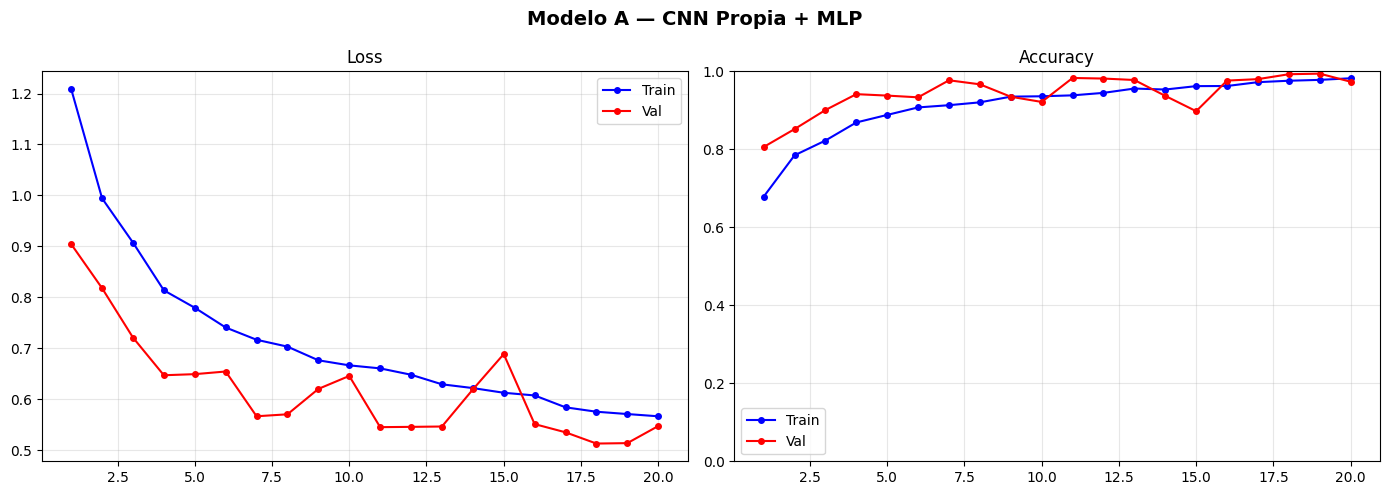


=== Modelo A ===
Test Accuracy : 0.9948
Test F1 (weighted): 0.9948
                    precision    recall  f1-score   support

   Black Sea Sprat       0.99      1.00      1.00       141
   Gilt-Head Bream       1.00      0.96      0.98       148
   Hourse Mackerel       1.00      1.00      1.00       142
        Red Mullet       1.00      1.00      1.00       147
     Red Sea Bream       1.00      1.00      1.00       140
          Sea Bass       0.96      0.99      0.98       159
            Shrimp       1.00      1.00      1.00       154
Striped Red Mullet       1.00      1.00      1.00       163
             Trout       1.00      1.00      1.00       156

          accuracy                           0.99      1350
         macro avg       1.00      0.99      0.99      1350
      weighted avg       0.99      0.99      0.99      1350



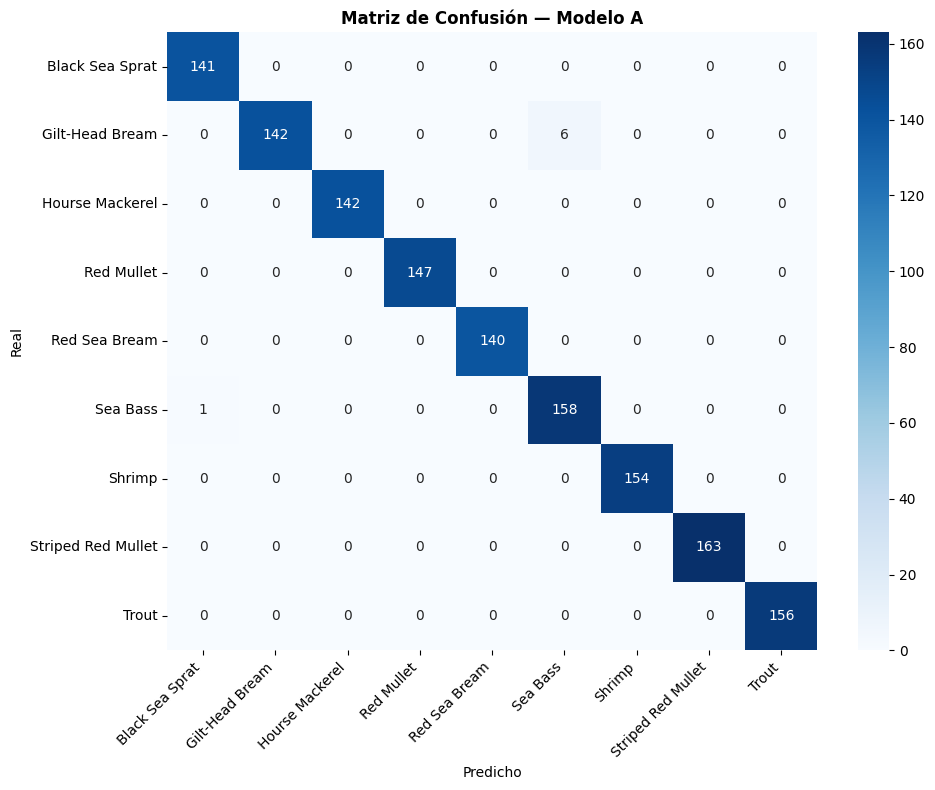

In [42]:
plot_history(history_a, 'Modelo A — CNN Propia + MLP')
modelo_a.load_state_dict(torch.load('modelo_a_best.pth'))
labels_a, preds_a, acc_a, f1_a = evaluate_test(modelo_a, test_loader, CLASS_NAMES, 'Modelo A')
plot_cm(labels_a, preds_a, CLASS_NAMES, 'Modelo A')

## 10. Entrenamiento Modelo B (ResNet50 + MLP)




**Fase 1:** Backbone congelado, solo se entrena la MLP. Esto permite que la MLP
aprenda a interpretar los features de ResNet50 sin desestabilizar el backbone.

**Fase 2:** Se descongela el último bloque residual (`layer4`) para fine-tuning.
Se usa un learning rate más bajo para no destruir los pesos preentrenados.

In [43]:
# ── FASE 1: Solo entrena la MLP ──
params_train_b1 = sum(p.numel() for p in modelo_b.parameters() if p.requires_grad)
print(f'Fase 1 — parámetros entrenables: {params_train_b1:,} (solo MLP)')

opt_b1 = optim.Adam(filter(lambda p: p.requires_grad, modelo_b.parameters()), lr=LR_B1)
sch_b1 = optim.lr_scheduler.ReduceLROnPlateau(opt_b1, patience=3, factor=0.5)

print('='*60)
print('MODELO B — FASE 1: ResNet50 congelado, entrenando MLP')
print('='*60)
history_b1, _ = training_loop(
    modelo_b, train_loader, val_loader, criterion, opt_b1, sch_b1,
    EPOCHS_B1, 'Modelo B Fase1', 'modelo_b_phase1.pth'
)

Fase 1 — parámetros entrenables: 1,216,265 (solo MLP)
MODELO B — FASE 1: ResNet50 congelado, entrenando MLP
[Modelo B Fase1] Ep 01/8 | Train 0.8363 (0.9253) | Val 0.9881 (0.5785) ← best
[Modelo B Fase1] Ep 02/8 | Train 0.9568 (0.6658) | Val 0.9993 (0.5426) ← best
[Modelo B Fase1] Ep 03/8 | Train 0.9783 (0.6089) | Val 0.9993 (0.5271) ← best
[Modelo B Fase1] Ep 04/8 | Train 0.9813 (0.5868) | Val 0.9985 (0.5145)
[Modelo B Fase1] Ep 05/8 | Train 0.9867 (0.5680) | Val 0.9970 (0.5147)
[Modelo B Fase1] Ep 06/8 | Train 0.9857 (0.5622) | Val 0.9956 (0.5138)
[Modelo B Fase1] Ep 07/8 | Train 0.9890 (0.5544) | Val 0.9978 (0.5054)
[Modelo B Fase1] Ep 08/8 | Train 0.9917 (0.5462) | Val 0.9978 (0.5026)
⏱ 12.7 min | Mejor val acc: 0.9993


In [44]:
# ── FASE 2: Fine-tuning del último bloque ──
modelo_b.unfreeze_last_block()
params_train_b2 = sum(p.numel() for p in modelo_b.parameters() if p.requires_grad)
print(f'Fase 2 — parámetros entrenables: {params_train_b2:,} (MLP + layer4)')

opt_b2 = optim.Adam(filter(lambda p: p.requires_grad, modelo_b.parameters()),
                    lr=LR_B2, weight_decay=1e-4)
sch_b2 = optim.lr_scheduler.CosineAnnealingLR(opt_b2, T_max=EPOCHS_B2)

print('='*60)
print('MODELO B — FASE 2: Fine-tuning layer4 + MLP')
print('='*60)
history_b2, time_b = training_loop(
    modelo_b, train_loader, val_loader, criterion, opt_b2, sch_b2,
    EPOCHS_B2, 'Modelo B Fase2', 'modelo_b_best.pth'
)

history_b = {k: history_b1[k] + history_b2[k] for k in history_b1}

Fase 2 — parámetros entrenables: 16,181,001 (MLP + layer4)
MODELO B — FASE 2: Fine-tuning layer4 + MLP
[Modelo B Fase2] Ep 01/8 | Train 0.9952 (0.5300) | Val 1.0000 (0.4938) ← best


/tmp/ipykernel_12242/3781272567.py:37: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  if scheduler: scheduler.step(vl)


[Modelo B Fase2] Ep 02/8 | Train 0.9984 (0.5176) | Val 1.0000 (0.4911) ← best
[Modelo B Fase2] Ep 03/8 | Train 0.9989 (0.5132) | Val 1.0000 (0.4901) ← best
[Modelo B Fase2] Ep 04/8 | Train 0.9995 (0.5110) | Val 1.0000 (0.4895) ← best
[Modelo B Fase2] Ep 05/8 | Train 0.9997 (0.5087) | Val 1.0000 (0.4881) ← best
[Modelo B Fase2] Ep 06/8 | Train 0.9995 (0.5091) | Val 1.0000 (0.4881) ← best
[Modelo B Fase2] Ep 07/8 | Train 0.9994 (0.5082) | Val 1.0000 (0.4877) ← best
[Modelo B Fase2] Ep 08/8 | Train 1.0000 (0.5059) | Val 1.0000 (0.4878) ← best
⏱ 12.9 min | Mejor val acc: 1.0000


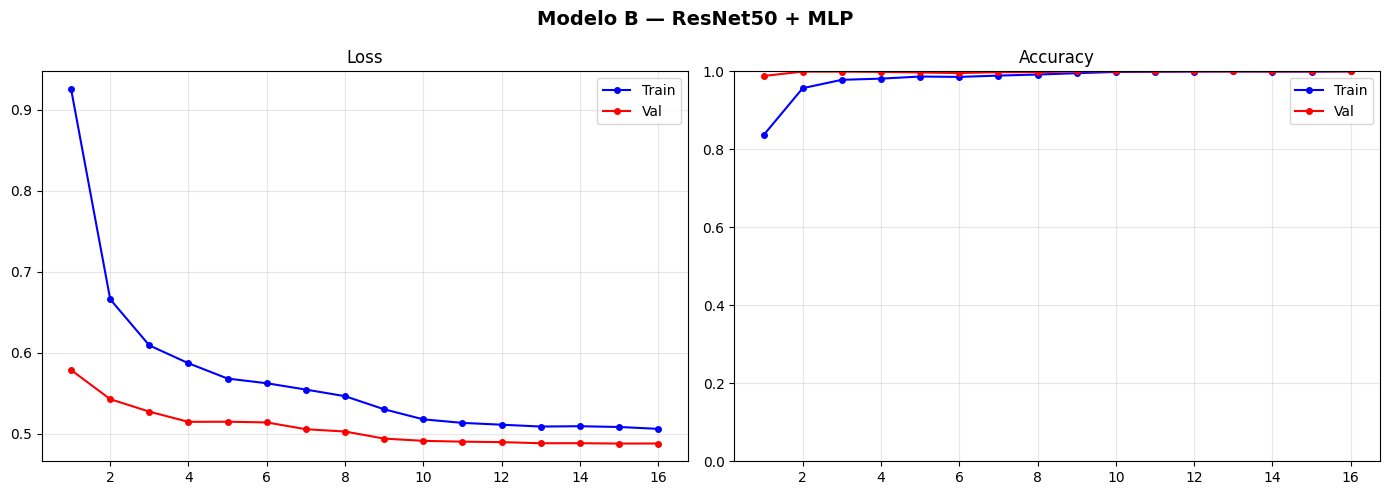


=== Modelo B ===
Test Accuracy : 1.0000
Test F1 (weighted): 1.0000
                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      1.00      1.00       141
   Gilt-Head Bream       1.00      1.00      1.00       148
   Hourse Mackerel       1.00      1.00      1.00       142
        Red Mullet       1.00      1.00      1.00       147
     Red Sea Bream       1.00      1.00      1.00       140
          Sea Bass       1.00      1.00      1.00       159
            Shrimp       1.00      1.00      1.00       154
Striped Red Mullet       1.00      1.00      1.00       163
             Trout       1.00      1.00      1.00       156

          accuracy                           1.00      1350
         macro avg       1.00      1.00      1.00      1350
      weighted avg       1.00      1.00      1.00      1350



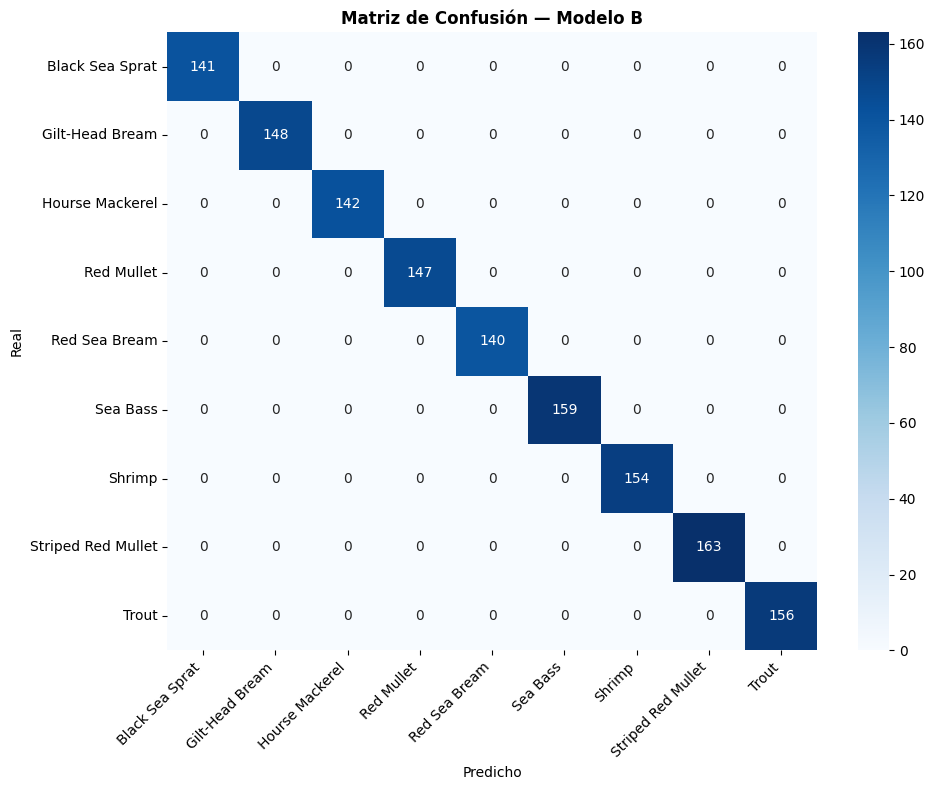

In [45]:
plot_history(history_b, 'Modelo B — ResNet50 + MLP')
modelo_b.load_state_dict(torch.load('modelo_b_best.pth'))
labels_b, preds_b, acc_b, f1_b = evaluate_test(modelo_b, test_loader, CLASS_NAMES, 'Modelo B')
plot_cm(labels_b, preds_b, CLASS_NAMES, 'Modelo B')

## 11. Entrenamiento Modelo C (VGG16 + MLP)


In [46]:
# ── FASE 1: Solo entrena la MLP ──
params_train_c1 = sum(p.numel() for p in modelo_c.parameters() if p.requires_grad)
print(f'Fase 1 — parámetros entrenables: {params_train_c1:,} (solo MLP)')

opt_c1 = optim.Adam(filter(lambda p: p.requires_grad, modelo_c.parameters()), lr=LR_C1)
sch_c1 = optim.lr_scheduler.ReduceLROnPlateau(opt_c1, patience=3, factor=0.5)

print('='*60)
print('MODELO C — FASE 1: VGG16 congelado, entrenando MLP')
print('='*60)
history_c1, _ = training_loop(
    modelo_c, train_loader, val_loader, criterion, opt_c1, sch_c1,
    EPOCHS_C1, 'Modelo C Fase1', 'modelo_c_phase1.pth'
)

Fase 1 — parámetros entrenables: 429,833 (solo MLP)
MODELO C — FASE 1: VGG16 congelado, entrenando MLP
[Modelo C Fase1] Ep 01/8 | Train 0.8376 (0.9332) | Val 0.9919 (0.5779) ← best
[Modelo C Fase1] Ep 02/8 | Train 0.9556 (0.6722) | Val 0.9948 (0.5441) ← best
[Modelo C Fase1] Ep 03/8 | Train 0.9665 (0.6279) | Val 0.9948 (0.5321) ← best
[Modelo C Fase1] Ep 04/8 | Train 0.9773 (0.6005) | Val 0.9993 (0.5160) ← best
[Modelo C Fase1] Ep 05/8 | Train 0.9794 (0.5873) | Val 0.9963 (0.5197)
[Modelo C Fase1] Ep 06/8 | Train 0.9794 (0.5794) | Val 0.9963 (0.5179)
[Modelo C Fase1] Ep 07/8 | Train 0.9813 (0.5717) | Val 0.9963 (0.5115)
[Modelo C Fase1] Ep 08/8 | Train 0.9862 (0.5603) | Val 0.9956 (0.5124)
⏱ 13.3 min | Mejor val acc: 0.9993


In [47]:
# ── FASE 2: Fine-tuning del último bloque convolucional ──
modelo_c.unfreeze_last_block()
params_train_c2 = sum(p.numel() for p in modelo_c.parameters() if p.requires_grad)
print(f'Fase 2 — parámetros entrenables: {params_train_c2:,} (MLP + último bloque VGG16)')

opt_c2 = optim.Adam(filter(lambda p: p.requires_grad, modelo_c.parameters()),
                    lr=LR_C2, weight_decay=1e-4)
sch_c2 = optim.lr_scheduler.CosineAnnealingLR(opt_c2, T_max=EPOCHS_C2)

print('='*60)
print('MODELO C — FASE 2: Fine-tuning último bloque VGG16 + MLP')
print('='*60)
history_c2, time_c = training_loop(
    modelo_c, train_loader, val_loader, criterion, opt_c2, sch_c2,
    EPOCHS_C2, 'Modelo C Fase2', 'modelo_c_best.pth'
)

history_c = {k: history_c1[k] + history_c2[k] for k in history_c1}

Fase 2 — parámetros entrenables: 7,509,257 (MLP + último bloque VGG16)
MODELO C — FASE 2: Fine-tuning último bloque VGG16 + MLP
[Modelo C Fase2] Ep 01/8 | Train 0.9857 (0.5534) | Val 0.9993 (0.4983) ← best


/tmp/ipykernel_12242/3781272567.py:37: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  if scheduler: scheduler.step(vl)


[Modelo C Fase2] Ep 02/8 | Train 0.9943 (0.5298) | Val 0.9896 (0.5150)
[Modelo C Fase2] Ep 03/8 | Train 0.9973 (0.5201) | Val 0.9993 (0.4926) ← best
[Modelo C Fase2] Ep 04/8 | Train 0.9987 (0.5162) | Val 1.0000 (0.4904) ← best
[Modelo C Fase2] Ep 05/8 | Train 0.9989 (0.5144) | Val 0.9993 (0.4911)
[Modelo C Fase2] Ep 06/8 | Train 0.9981 (0.5144) | Val 1.0000 (0.4894) ← best
[Modelo C Fase2] Ep 07/8 | Train 0.9994 (0.5124) | Val 0.9993 (0.4899)
[Modelo C Fase2] Ep 08/8 | Train 0.9984 (0.5128) | Val 1.0000 (0.4891) ← best
⏱ 13.4 min | Mejor val acc: 1.0000


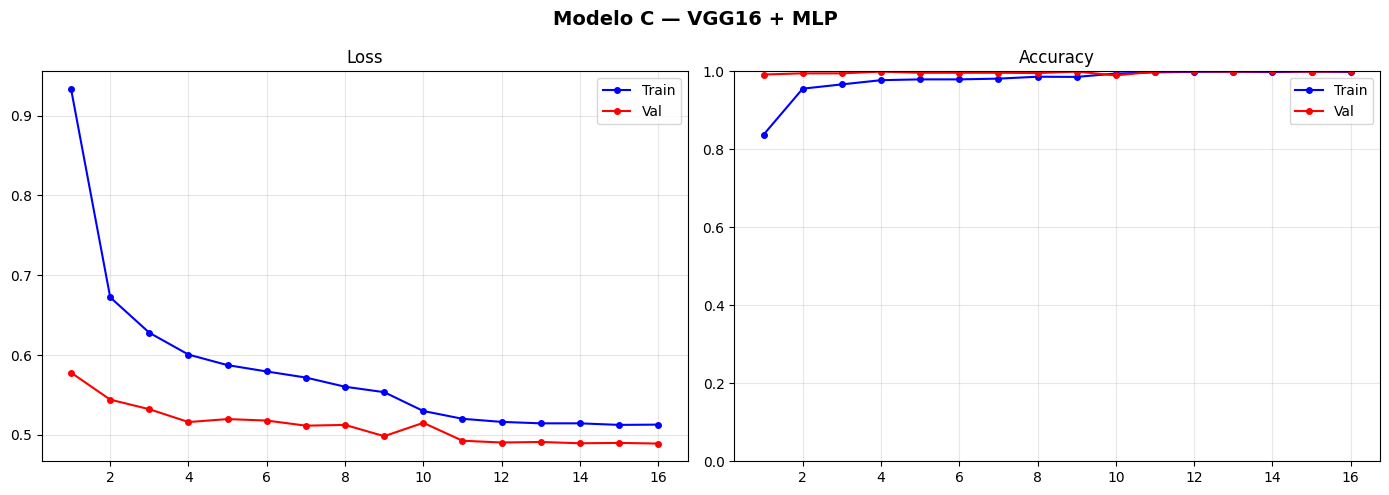


=== Modelo C ===
Test Accuracy : 1.0000
Test F1 (weighted): 1.0000
                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      1.00      1.00       141
   Gilt-Head Bream       1.00      1.00      1.00       148
   Hourse Mackerel       1.00      1.00      1.00       142
        Red Mullet       1.00      1.00      1.00       147
     Red Sea Bream       1.00      1.00      1.00       140
          Sea Bass       1.00      1.00      1.00       159
            Shrimp       1.00      1.00      1.00       154
Striped Red Mullet       1.00      1.00      1.00       163
             Trout       1.00      1.00      1.00       156

          accuracy                           1.00      1350
         macro avg       1.00      1.00      1.00      1350
      weighted avg       1.00      1.00      1.00      1350



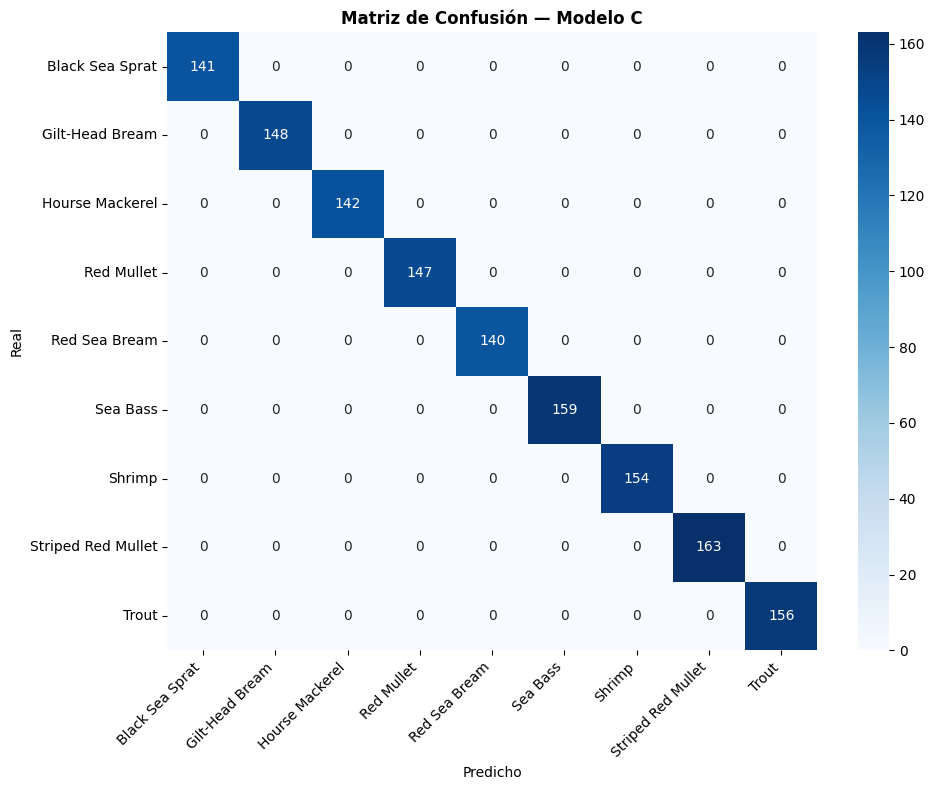

In [48]:
plot_history(history_c, 'Modelo C — VGG16 + MLP')
modelo_c.load_state_dict(torch.load('modelo_c_best.pth'))
labels_c, preds_c, acc_c, f1_c = evaluate_test(modelo_c, test_loader, CLASS_NAMES, 'Modelo C')
plot_cm(labels_c, preds_c, CLASS_NAMES, 'Modelo C')

## 12. Comparación Final

In [49]:
results = pd.DataFrame({
    'Modelo'              : ['Modelo A — CNN Propia + MLP', 'Modelo B — ResNet50 + MLP', 'Modelo C — VGG16 + MLP'],
    'Backbone'            : ['CNN desde cero', 'ResNet50 (ImageNet)', 'VGG16 (ImageNet)'],
    'MLP'                 : ['FishMLP (128→256→128→9)', 'FishMLP (2048→512→256→128→9)', 'FishMLP (512→256→128→9)'],
    'Parámetros totales'  : [f'{params_a:,}', f'{params_b_total:,}', f'{params_c_total:,}'],
    'Epochs'              : [EPOCHS_A, EPOCHS_B1 + EPOCHS_B2, EPOCHS_C1 + EPOCHS_C2],
    'Test Accuracy'       : [f'{acc_a:.4f}', f'{acc_b:.4f}', f'{acc_c:.4f}'],
    'Test F1 (weighted)'  : [f'{f1_a:.4f}', f'{f1_b:.4f}', f'{f1_c:.4f}'],
    'Tiempo entrenamiento': [f'{time_a/60:.1f} min', f'{time_b/60:.1f} min', f'{time_c/60:.1f} min'],
})
print('\n' + '='*70)
print('TABLA COMPARATIVA FINAL')
print('='*70)
print(results.T.to_string())


TABLA COMPARATIVA FINAL
                                                0                             1                        2
Modelo                Modelo A — CNN Propia + MLP     Modelo B — ResNet50 + MLP   Modelo C — VGG16 + MLP
Backbone                           CNN desde cero           ResNet50 (ImageNet)         VGG16 (ImageNet)
MLP                       FishMLP (128→256→128→9)  FishMLP (2048→512→256→128→9)  FishMLP (512→256→128→9)
Parámetros totales                        520,681                    24,724,297               15,144,521
Epochs                                         20                            16                       16
Test Accuracy                              0.9948                        1.0000                   1.0000
Test F1 (weighted)                         0.9948                        1.0000                   1.0000
Tiempo entrenamiento                     32.4 min                      12.9 min                 13.4 min


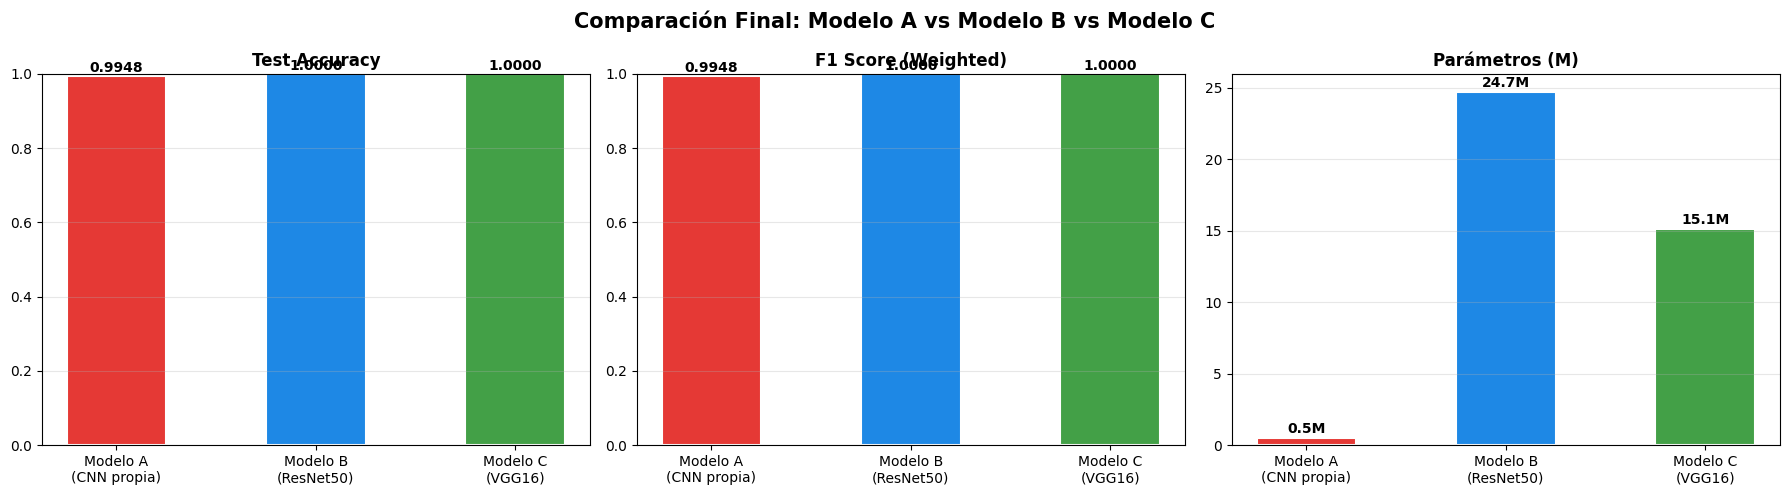

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación Final: Modelo A vs Modelo B vs Modelo C', fontsize=15, fontweight='bold')
nombres = ['Modelo A\n(CNN propia)', 'Modelo B\n(ResNet50)', 'Modelo C\n(VGG16)']
colores = ['#E53935', '#1E88E5', '#43A047']

for ax, vals, title, ylim in zip(
    axes,
    [[acc_a, acc_b, acc_c], [f1_a, f1_b, f1_c], [params_a/1e6, params_b_total/1e6, params_c_total/1e6]],
    ['Test Accuracy', 'F1 Score (Weighted)', 'Parámetros (M)'],
    [1, 1, None]
):
    bars = ax.bar(nombres, vals, color=colores, width=0.5, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    if ylim: ax.set_ylim(0, ylim)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if ylim else 0.3),
                f'{v:.4f}' if ylim else f'{v:.1f}M', ha='center', fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_final.png', dpi=150)
plt.show()

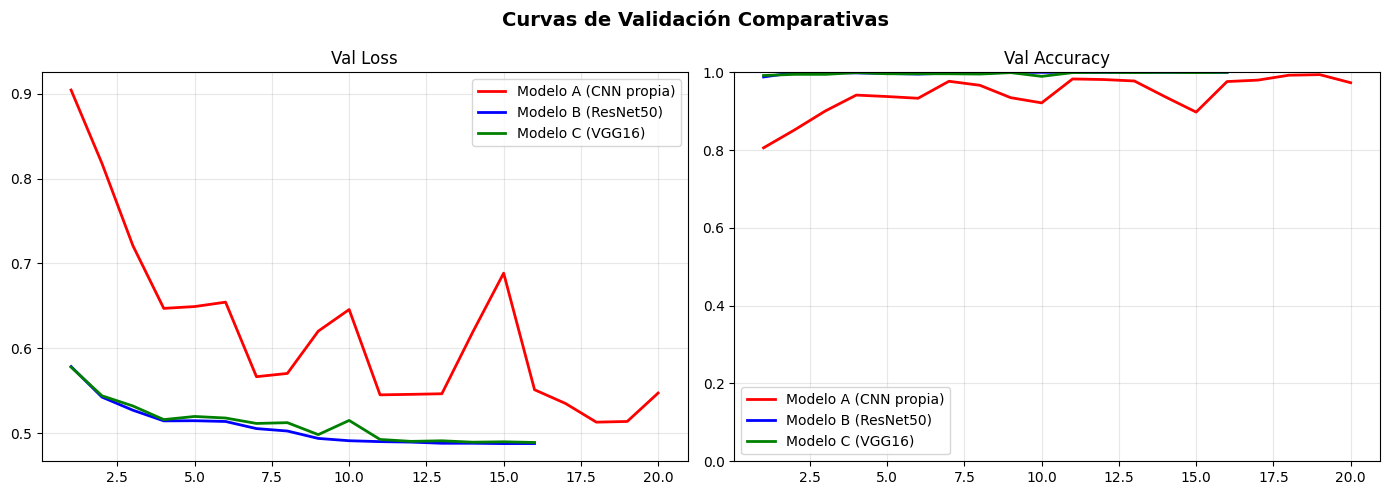


 Análisis completo. Todos los gráficos guardados.


In [51]:
# ── Curvas de validación superpuestas ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep_a = range(1, len(history_a['val_acc'])+1)
ep_b = range(1, len(history_b['val_acc'])+1)
ep_c = range(1, len(history_c['val_acc'])+1)

ax1.plot(ep_a, history_a['val_loss'], 'r-', lw=2, label='Modelo A (CNN propia)')
ax1.plot(ep_b, history_b['val_loss'], 'b-', lw=2, label='Modelo B (ResNet50)')
ax1.plot(ep_c, history_c['val_loss'], 'g-', lw=2, label='Modelo C (VGG16)')
ax1.set_title('Val Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_a, history_a['val_acc'], 'r-', lw=2, label='Modelo A (CNN propia)')
ax2.plot(ep_b, history_b['val_acc'], 'b-', lw=2, label='Modelo B (ResNet50)')
ax2.plot(ep_c, history_c['val_acc'], 'g-', lw=2, label='Modelo C (VGG16)')
ax2.set_title('Val Accuracy'); ax2.set_ylim(0,1); ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle('Curvas de Validación Comparativas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_comparativas.png', dpi=100)
plt.show()

print('\n Análisis completo. Todos los gráficos guardados.')

## 12. Conclusiones

### ¿Qué mide esta comparación?
Como la MLP es **idéntica** en los tres modelos, la única diferencia es el **backbone**:
- **Modelo A** — CNN propia desde cero: aprende features específicos del dataset de peces
- **Modelo B** — ResNet50: arquitectura profunda con skip connections, preentrenada en ImageNet
- **Modelo C** — VGG16: arquitectura secuencial sin skip connections, preentrenada en ImageNet

### ResNet50 vs VGG16
Ambos parten del mismo preentrenamiento (ImageNet) con la misma estrategia (Transfer Learning + fine-tuning). La diferencia entre ellos refleja el impacto de la **arquitectura del backbone**:
- ResNet50 tiene skip connections que facilitan el flujo del gradiente → mejor generalización en tareas nuevas
- VGG16 es más simple pero más antiguo → puede ser suficiente para tareas con imágenes controladas

### Limitaciones del dataset
Las imágenes presentan fondo tipo lona azul con condiciones controladas de iluminación. Esto reduce la complejidad de la tarea y explica los altos valores de accuracy en los tres modelos. En un escenario real con imágenes en ambiente natural, se esperaría mayor diferencia entre los modelos.

### ¿Cuándo usar cada uno?
| Escenario | Recomendado |
|-----------|-------------|
| Dataset pequeño, dominio similar a fotos naturales | ResNet50 o VGG16 con TL |
| Dataset grande, dominio específico | CNN propia |
| Restricción de parámetros / deployment edge | CNN propia (más liviana) |
| Máxima precisión sin restricciones | ResNet50 con TL |